In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path

from config import DATASETS, DRIFTER_COLUMNS
from utils import (
    compute_M, load_dataset_files, load_drifter_file, luq_case,
    prep_dataset, prep_drifter, to_epoch_seconds_datetime64
)

LOCAL_CASE_STUDIES_DIR = Path("/Users/jcreest/Documents/FRESH-CARE/WP1/case_studies/")
LOCAL_RESULTS_DIR = Path("/Users/jcreest/Documents/FRESH-CARE/WP1/data/luq_new/")
LOCAL_DRIFTERS_DIR = Path("/Users/jcreest/Documents/FRESH-CARE/WP1/selected_drifters_new/")

for name in DATASETS:
    DATASETS[name]["path"] = str(LOCAL_CASE_STUDIES_DIR)

def _load_field_cropped(name, t0_dt, tau_sec, lon0_deg, lat0_deg, margin):
    t_start = t0_dt.strftime("%Y-%m-%d")
    t_end = (t0_dt + pd.Timedelta(seconds=int(tau_sec)) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
    
    ds = load_dataset_files(
        DATASETS[name]["path"], 
        pattern=f"{name}*.nc",
        eval_start=t_start, 
        eval_end=t_end
    )
    
    lon_name = DATASETS[name]["lon_name"]
    lat_name = DATASETS[name]["lat_name"]
    lon_vals = ds[lon_name].values
    lat_vals = ds[lat_name].values
    
    lon0_crop = lon0_deg
    if lon_vals.min() >= 0 and lon0_deg < 0:
        lon0_crop = lon0_deg + 360
    elif lon_vals.max() <= 180 and lon0_deg > 180:
        lon0_crop = lon0_deg - 360
        
    low = lon0_crop - margin
    high = lon0_crop + margin
    
    if lon_vals.min() >= 0 and low < 0:
        lon_mask = (lon_vals <= high) | (lon_vals >= 360 + low)
    else:
        lon_mask = (lon_vals >= low) & (lon_vals <= high)
        
    lat_mask = (lat_vals >= lat0_deg - margin) & (lat_vals <= lat0_deg + margin)
    
    lon_dim = ds[lon_name].dims[0]
    lat_dim = ds[lat_name].dims[0]
    ds = ds.isel({lon_dim: np.where(lon_mask)[0], lat_dim: np.where(lat_mask)[0]})
    
    field = prep_dataset(
        ds,
        u_name=DATASETS[name]["u_name"],
        v_name=DATASETS[name]["v_name"],
        time_name=DATASETS[name]["time_name"],
        lat_name=lat_name,
        lon_name=lon_name,
    )
    ds.close()
    return field

In [2]:
# ==========================================
# PARAMETER CHANGES
# ==========================================

CASES = {
    "BST": {"t0": "2016-10-04 00:00:00", "csv": "luq_results_drifter_300234063229590_2016-10-04_BST.csv"},
    "LFG": {"t0": "2021-09-25 00:00:00", "csv": "luq_results_drifter_300234066217780_2021-09-09_LFG.csv"},
    "WSC": {"t0": "2016-11-18 00:00:00", "csv": "luq_results_drifter_145931_2016-11-18_WSC.csv"},
    "EGC": {"t0": "2017-06-01 00:00:00", "csv": "luq_results_drifter_300234063253890_2017-05-30_EGC.csv"},
    "BSO": {"t0": "2017-01-17 00:00:00", "csv": "luq_results_drifter_145901_2016-12-09_BSO.csv"},
    "BEA": {"t0": "2020-09-01 00:00:00", "csv": "luq_results_drifter_300534060314460_2020-09-01_BEA.csv"},
    "GST": {"t0": "2016-08-01 00:00:00", "csv": "luq_results_drifter_300234062954450_2016-05-24_GST.csv"},
    "LBC": {"t0": "2015-10-18 00:00:00", "csv": "luq_results_drifter_300234062954450_2015-08-28_LBC.csv"},
    "TPD": {"t0": "2018-12-15 00:00:00", "csv": "luq_results_drifter_300234065800000_2018-10-24_TPD.csv"},
}

TAU_DAYS = 5                         
R_KM = 5                            

MARGIN_CROP = 40.0                   
MARGIN_M_MAP = 2.0                   
RESOLUTION = 500                     

PLOT_LUQ = True
PLOT_M = True

In [3]:
CASE_ID = "LFG"

RESULTS_CSV = CASES[CASE_ID]["csv"]
T0_STR = CASES[CASE_ID]["t0"]
DATASET_NAME = "AVISO"

In [4]:
# Load and prepare times
t0_dt = pd.to_datetime(T0_STR)
tau_sec = np.int64(TAU_DAYS * 24 * 3600)
t0_sec = to_epoch_seconds_datetime64(np.array([t0_dt.to_datetime64()], dtype="datetime64[s]"))[0]

# Read csv to extract data
csv_results = pd.read_csv(LOCAL_RESULTS_DIR / RESULTS_CSV, sep=";")
timeseries_df = csv_results[csv_results["data_type"] == "timeseries"].copy()
timeseries_df["t0_datetime"] = pd.to_datetime(timeseries_df["t0_datetime"])

# Find coordinates of t0
ref_row = timeseries_df[timeseries_df["t0_datetime"] == t0_dt].iloc[0]
lon0_deg = ref_row["lon0_deg"]
lat0_deg = ref_row["lat0_deg"]
lon0_rad = np.float32(np.deg2rad(lon0_deg))
lat0_rad = np.float32(np.deg2rad(lat0_deg))

# Read drifter track
drifter_filename = csv_results[csv_results["data_type"] == "summary"]["drifter_filename"].iloc[0]
df_drift = load_drifter_file(LOCAL_DRIFTERS_DIR / drifter_filename)
drifter = prep_drifter(df_drift, time_col=DRIFTER_COLUMNS["time_col"], lon_col=DRIFTER_COLUMNS["lon_col"], lat_col=DRIFTER_COLUMNS["lat_col"])

t_target_sec = t0_sec + tau_sec
idx = int(np.argmin(np.abs(drifter["time_sec"] - t_target_sec)))
lon_target = drifter["lon_rad"][idx]
lat_target = drifter["lat_rad"][idx]

print(f"Initial point found in: Lon {lon0_deg:.2f}, Lat {lat0_deg:.2f}")

# Load product data
print(f"Loading {DATASET_NAME}...")
field = _load_field_cropped(DATASET_NAME, t0_dt, tau_sec, lon0_deg, lat0_deg, MARGIN_CROP)

# Compute LUQ and M matrices
M_grid = None
luq_dict = None

if PLOT_LUQ:
    print("Computing LUQ...")
    luq_mean_km, valid_frac, seed_lon_grid, seed_lat_grid, LUQ_grid_km, valid_grid = luq_case(
        field, t0_sec, tau_sec, DATASETS[DATASET_NAME].get("dt_sec", 3600),
        lon0_rad, lat0_rad, lon_target, lat_target, R_KM, return_map=True
    )
    luq_dict = {
        "lon_deg": np.rad2deg(seed_lon_grid),
        "lat_deg": np.rad2deg(seed_lat_grid),
        "luq_km": LUQ_grid_km
    }

if PLOT_M:
    print(f"Computing M MAP ({RESOLUTION}x{RESOLUTION})...")
    lon_grid = np.linspace(np.deg2rad(lon0_deg - MARGIN_M_MAP), np.deg2rad(lon0_deg + MARGIN_M_MAP), RESOLUTION, dtype=np.float32)
    lat_grid = np.linspace(np.deg2rad(lat0_deg - MARGIN_M_MAP), np.deg2rad(lat0_deg + MARGIN_M_MAP), RESOLUTION, dtype=np.float32)
    M_grid = compute_M(field, t0_sec, tau_sec, DATASETS[DATASET_NAME].get("dt_sec", 3600), lon_grid, lat_grid)
    lon_deg_grid = np.rad2deg(lon_grid)
    lat_deg_grid = np.rad2deg(lat_grid)
    lon_mesh, lat_mesh = np.meshgrid(lon_deg_grid, lat_deg_grid)

print("Finished!")

Initial point found in: Lon 2.83, Lat 69.47
Loading AVISO...
  Loading 7 of 63 files
Computing LUQ...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Computing M MAP (500x500)...
Finished!


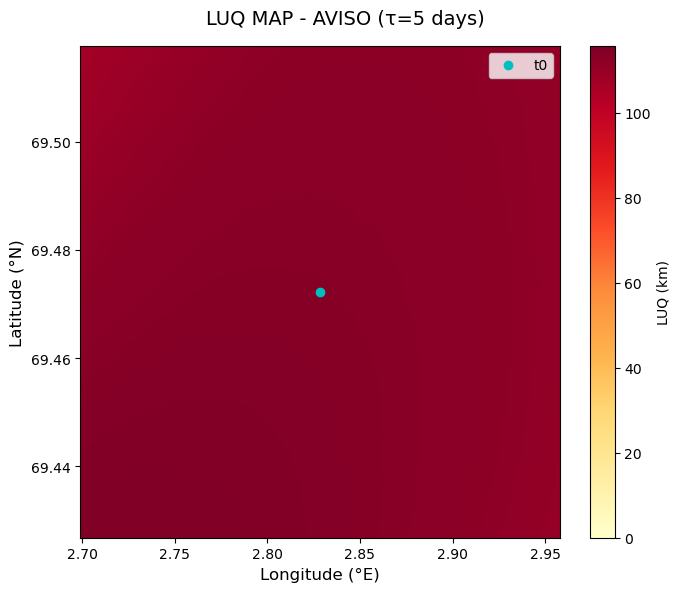

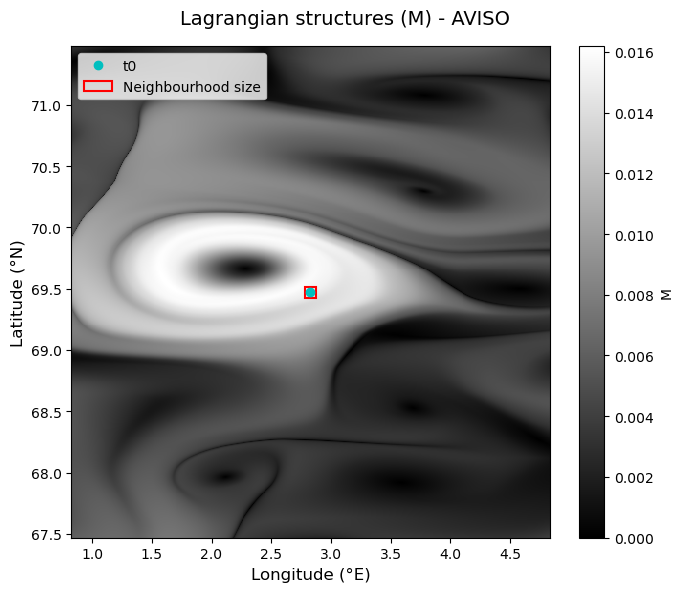

In [5]:
# --- PLOT LUQ MAP ---
if PLOT_LUQ and luq_dict is not None:
    fig, ax = plt.subplots(figsize=(7, 6))
    pcm = ax.pcolormesh(
        luq_dict["lon_deg"], luq_dict["lat_deg"], luq_dict["luq_km"],
        cmap="YlOrRd", vmin=0, shading="auto"
    )
    ax.plot(lon0_deg, lat0_deg, "co", markersize=6, label="t0")
    
    ax.set_xlabel(f"Longitude (°{'W' if lon0_deg < 0 else 'E'})", fontsize=12)
    ax.set_ylabel("Latitude (°N)", fontsize=12)
    plt.colorbar(pcm, ax=ax, label="LUQ (km)")
    ax.legend()
    fig.suptitle(f"LUQ MAP - {DATASET_NAME} (τ={TAU_DAYS} days)", fontsize=14)
    plt.tight_layout()
    plt.show()

# --- PLOT M MAP ---
if PLOT_M and M_grid is not None:
    r_km_deg = R_KM / 111.0
    rect = Rectangle(
        (lon0_deg - r_km_deg, lat0_deg - r_km_deg),
        2 * r_km_deg, 2 * r_km_deg,
        linewidth=1.5, edgecolor="red", facecolor="none", label=f"Neighbourhood size"
    )
    
    fig, ax = plt.subplots(figsize=(7, 6))
    pcm = ax.pcolormesh(lon_mesh, lat_mesh, M_grid, cmap="binary_r", vmin=0, shading="auto")
    ax.plot(lon0_deg, lat0_deg, "co", markersize=6, label="t0")
    ax.add_patch(rect)
    
    ax.set_xlabel(f"Longitude (°{'W' if lon0_deg < 0 else 'E'})", fontsize=12)
    ax.set_ylabel("Latitude (°N)", fontsize=12)
    plt.colorbar(pcm, ax=ax, label="M")
    ax.legend(loc="upper left")
    fig.suptitle(f"Lagrangian structures (M) - {DATASET_NAME}", fontsize=14)
    plt.tight_layout()
    plt.show()

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.patches import Rectangle

def plot_case_study_matrix(case_study_name, results_csv, t0_str, tau_days, r_km, 
                            margin_crop, margin_m_map, resolution):

    products = ["AVISO", "GLOBCURRENT", "OSCAR", "NEUROST", "GLORYS", "TOPAZ"]
    
    t0_dt = pd.to_datetime(t0_str)
    tau_sec = np.int64(tau_days * 24 * 3600)
    t0_sec = to_epoch_seconds_datetime64(np.array([t0_dt.to_datetime64()], dtype="datetime64[s]"))[0]

    csv_results = pd.read_csv(LOCAL_RESULTS_DIR / results_csv, sep=";")
    timeseries_df = csv_results[csv_results["data_type"] == "timeseries"].copy()
    timeseries_df["t0_datetime"] = pd.to_datetime(timeseries_df["t0_datetime"])

    ref_row = timeseries_df[timeseries_df["t0_datetime"] == t0_dt].iloc[0]
    lon0_deg = ref_row["lon0_deg"]
    lat0_deg = ref_row["lat0_deg"]
    lon0_rad = np.float32(np.deg2rad(lon0_deg))
    lat0_rad = np.float32(np.deg2rad(lat0_deg))

    drifter_filename = csv_results[csv_results["data_type"] == "summary"]["drifter_filename"].iloc[0]
    df_drift = load_drifter_file(LOCAL_DRIFTERS_DIR / drifter_filename)
    drifter = prep_drifter(df_drift, time_col=DRIFTER_COLUMNS["time_col"], lon_col=DRIFTER_COLUMNS["lon_col"], lat_col=DRIFTER_COLUMNS["lat_col"])

    t_target_sec = t0_sec + tau_sec
    idx = int(np.argmin(np.abs(drifter["time_sec"] - t_target_sec)))
    lon_target = drifter["lon_rad"][idx]
    lat_target = drifter["lat_rad"][idx]

    print(f"t0: Lon {lon0_deg:.2f}, Lat {lat0_deg:.2f}")

    # Pre-generate matrix
    lon_grid = np.linspace(np.deg2rad(lon0_deg - margin_m_map), np.deg2rad(lon0_deg + margin_m_map), resolution, dtype=np.float32)
    lat_grid = np.linspace(np.deg2rad(lat0_deg - margin_m_map), np.deg2rad(lat0_deg + margin_m_map), resolution, dtype=np.float32)
    lon_deg_grid = np.rad2deg(lon_grid)
    lat_deg_grid = np.rad2deg(lat_grid)
    lon_mesh, lat_mesh = np.meshgrid(lon_deg_grid, lat_deg_grid)

    fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(15, 32))
    
    date_only = t0_dt.date()
    suptitle_str = f"{case_study_name} case | {date_only}\n$\\tau$ = {tau_days} days, $R$ = {r_km}km"
    fig.suptitle(suptitle_str, fontsize=18, fontweight='bold', y=0.98)

    for idx_prod, prod in enumerate(products):
        ax_m = axes[idx_prod, 0]   
        ax_luq = axes[idx_prod, 1]
        
        print(f"Processing {prod} ({idx_prod+1}/6)...")
        
        try:
            # Load currents
            field = _load_field_cropped(prod, t0_dt, tau_sec, lon0_deg, lat0_deg, margin_crop)
            dt_sec_prod = DATASETS[prod].get("dt_sec", 3600)
            
            # Compute LUQ
            luq_mean_km, valid_frac, seed_lon_grid, seed_lat_grid, LUQ_grid_km, valid_grid = luq_case(
                field, t0_sec, tau_sec, dt_sec_prod,
                lon0_rad, lat0_rad, lon_target, lat_target, r_km, return_map=True
            )
            
            # Compute M
            M_grid = compute_M(field, t0_sec, tau_sec, dt_sec_prod, lon_grid, lat_grid)
            
            # ----------------------------------------------------
            # Plot M Map
            # ----------------------------------------------------
            pcm_m = ax_m.pcolormesh(lon_mesh, lat_mesh, M_grid, cmap="binary_r", vmin=0, shading="auto")
            ax_m.plot(lon0_deg, lat0_deg, "co", markersize=6, label="t0")
            
            # Plot red square
            r_km_deg = r_km / 111.0
            rect = Rectangle(
                (lon0_deg - r_km_deg, lat0_deg - r_km_deg),
                2 * r_km_deg, 2 * r_km_deg,
                linewidth=1.5, edgecolor="red", facecolor="none", label=f"Neighbourhood size"
            )
            ax_m.add_patch(rect)
            ax_m.tick_params(axis='x', labelsize=13)
            ax_m.tick_params(axis='y', labelsize=13)

            ax_m.set_title(f"{chr(97+idx_prod)}) {prod}", fontsize=16, fontweight='bold', loc="left")
            
            ax_m.set_ylabel(f"Latitude (°N)", fontsize=14, fontweight="bold")
            if idx_prod == 5:  # Només l'última fila té label a l'eix X
                ax_m.set_xlabel(f"Longitude (°{'W' if lon0_deg < 0 else 'E'})", fontsize=14)
            ax_m.legend(loc="upper left", fontsize=12)
            
            cbar_m = fig.colorbar(pcm_m, ax=ax_m, label="M", pad=0.02)
            cbar_m.ax.tick_params(labelsize=12)
            cbar_m.set_label("M", fontsize=12)
            
            # ----------------------------------------------------
            # Plot LUQ map
            # ----------------------------------------------------
            pcm_luq = ax_luq.pcolormesh(
                np.rad2deg(seed_lon_grid), np.rad2deg(seed_lat_grid), LUQ_grid_km,
                cmap="YlOrRd", vmin=0, shading="auto"
            )
            ax_luq.plot(lon0_deg, lat0_deg, "co", markersize=6, label="t0")

            ax_luq.tick_params(axis='x', labelsize=13)
            ax_luq.tick_params(axis='y', labelsize=13)
            
            if idx_prod == 5:
                ax_luq.set_xlabel(f"Longitude (°{'W' if lon0_deg < 0 else 'E'})", fontsize=14)
            cbar_l = fig.colorbar(pcm_luq, ax=ax_luq, label="LUQ (km)", pad=0.02)
            cbar_l.ax.tick_params(labelsize=12)
            cbar_l.set_label("LUQ (km)", fontsize=12)
            
        except Exception as e:
            print(f"Error processing {prod}: {e}")
            ax_m.text(0.5, 0.5, f"No {prod} data", ha='center', va='center', color='red', transform=ax_m.transAxes)
            ax_luq.text(0.5, 0.5, "No data", ha='center', va='center', color='red', transform=ax_luq.transAxes)
            ax_m.set_ylabel(f"{prod}\n\nLatitude (°N)", fontsize=14, fontweight="bold")
    
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    
    out_name = f"M_plots/matrix_{case_study_name}_{t0_str.split()[0]}.png"
    plt.savefig(out_name, dpi=180, bbox_inches='tight')
    print(f"Matrix saved in: {out_name}")
    
    plt.show()

t0: Lon 2.83, Lat 69.47
Processing AVISO (1/6)...
  Loading 7 of 63 files
Processing GLOBCURRENT (2/6)...
  Loading 7 of 63 files
Processing OSCAR (3/6)...
  Loading 7 of 63 files
  INFO: Transposing from (time,lon,lat) to (time,lat,lon)
  INFO: Longitudes converted from [0,360] to [-180,180] and sorted
Processing NEUROST (4/6)...
  Loading 7 of 63 files
  INFO: Transposing NEUROST from (lat,lon,time) to (time,lat,lon)
  INFO: Longitudes converted from [0,360] to [-180,180] and sorted
Processing GLORYS (5/6)...
  Loading 7 of 63 files
Processing TOPAZ (6/6)...
  Loading 7 of 35 files
Matrix saved in: M_plots/matrix_LFG_2021-09-25.png


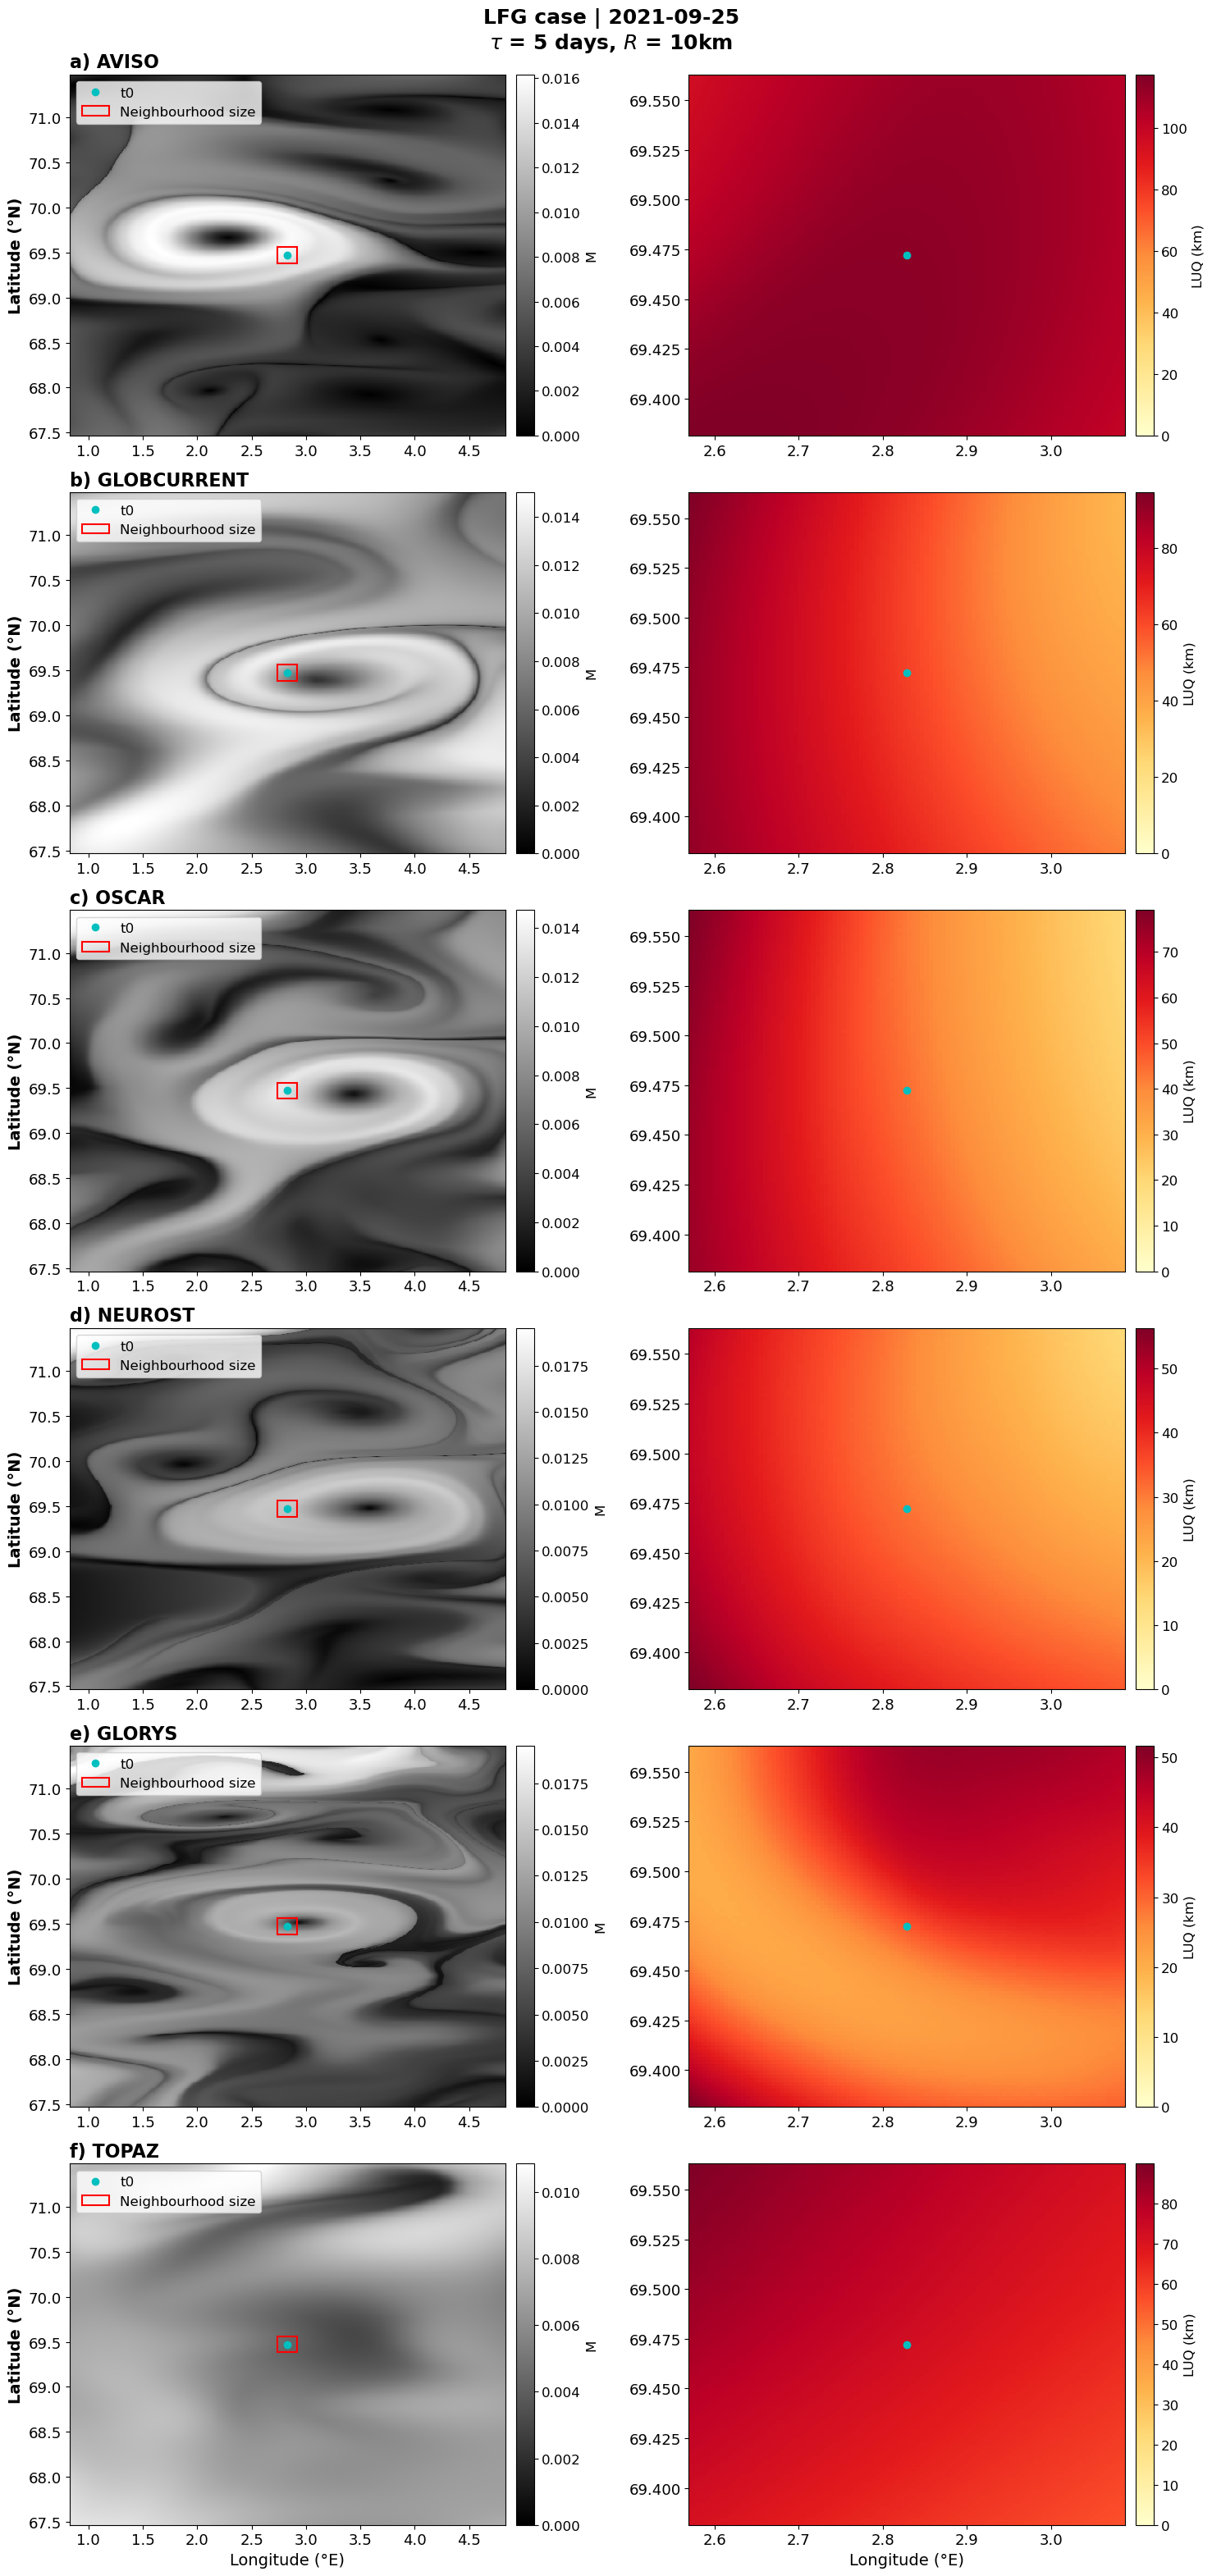

In [7]:
CASE_STUDY = "LFG"
TAU_DAYS = 5                         
R_KM = 10

RESULTS_CSV = CASES[CASE_STUDY]["csv"]
T0_STR = CASES[CASE_STUDY]["t0"]

plot_case_study_matrix(
    case_study_name=CASE_STUDY,  # El nom que vulguis que surti al títol (Ex: "Gran Canaria")
    results_csv=RESULTS_CSV,
    t0_str=T0_STR,
    tau_days=TAU_DAYS,
    r_km=R_KM,
    margin_crop=MARGIN_CROP,
    margin_m_map=MARGIN_M_MAP,
    resolution=RESOLUTION
)

t0: Lon -28.69, Lat 52.45
Processing AVISO (1/6)...
  Loading 7 of 63 files
Processing GLOBCURRENT (2/6)...
  Loading 7 of 63 files
Processing OSCAR (3/6)...
  Loading 7 of 63 files
  INFO: Transposing from (time,lon,lat) to (time,lat,lon)
  INFO: Longitudes converted from [0,360] to [-180,180] and sorted
Processing NEUROST (4/6)...
  Loading 7 of 63 files
  INFO: Transposing NEUROST from (lat,lon,time) to (time,lat,lon)
  INFO: Longitudes converted from [0,360] to [-180,180] and sorted
Processing GLORYS (5/6)...
  Loading 7 of 63 files
Processing TOPAZ (6/6)...
  Loading 7 of 35 files
Matrix saved in: M_plots/matrix_GST_2016-08-01.png


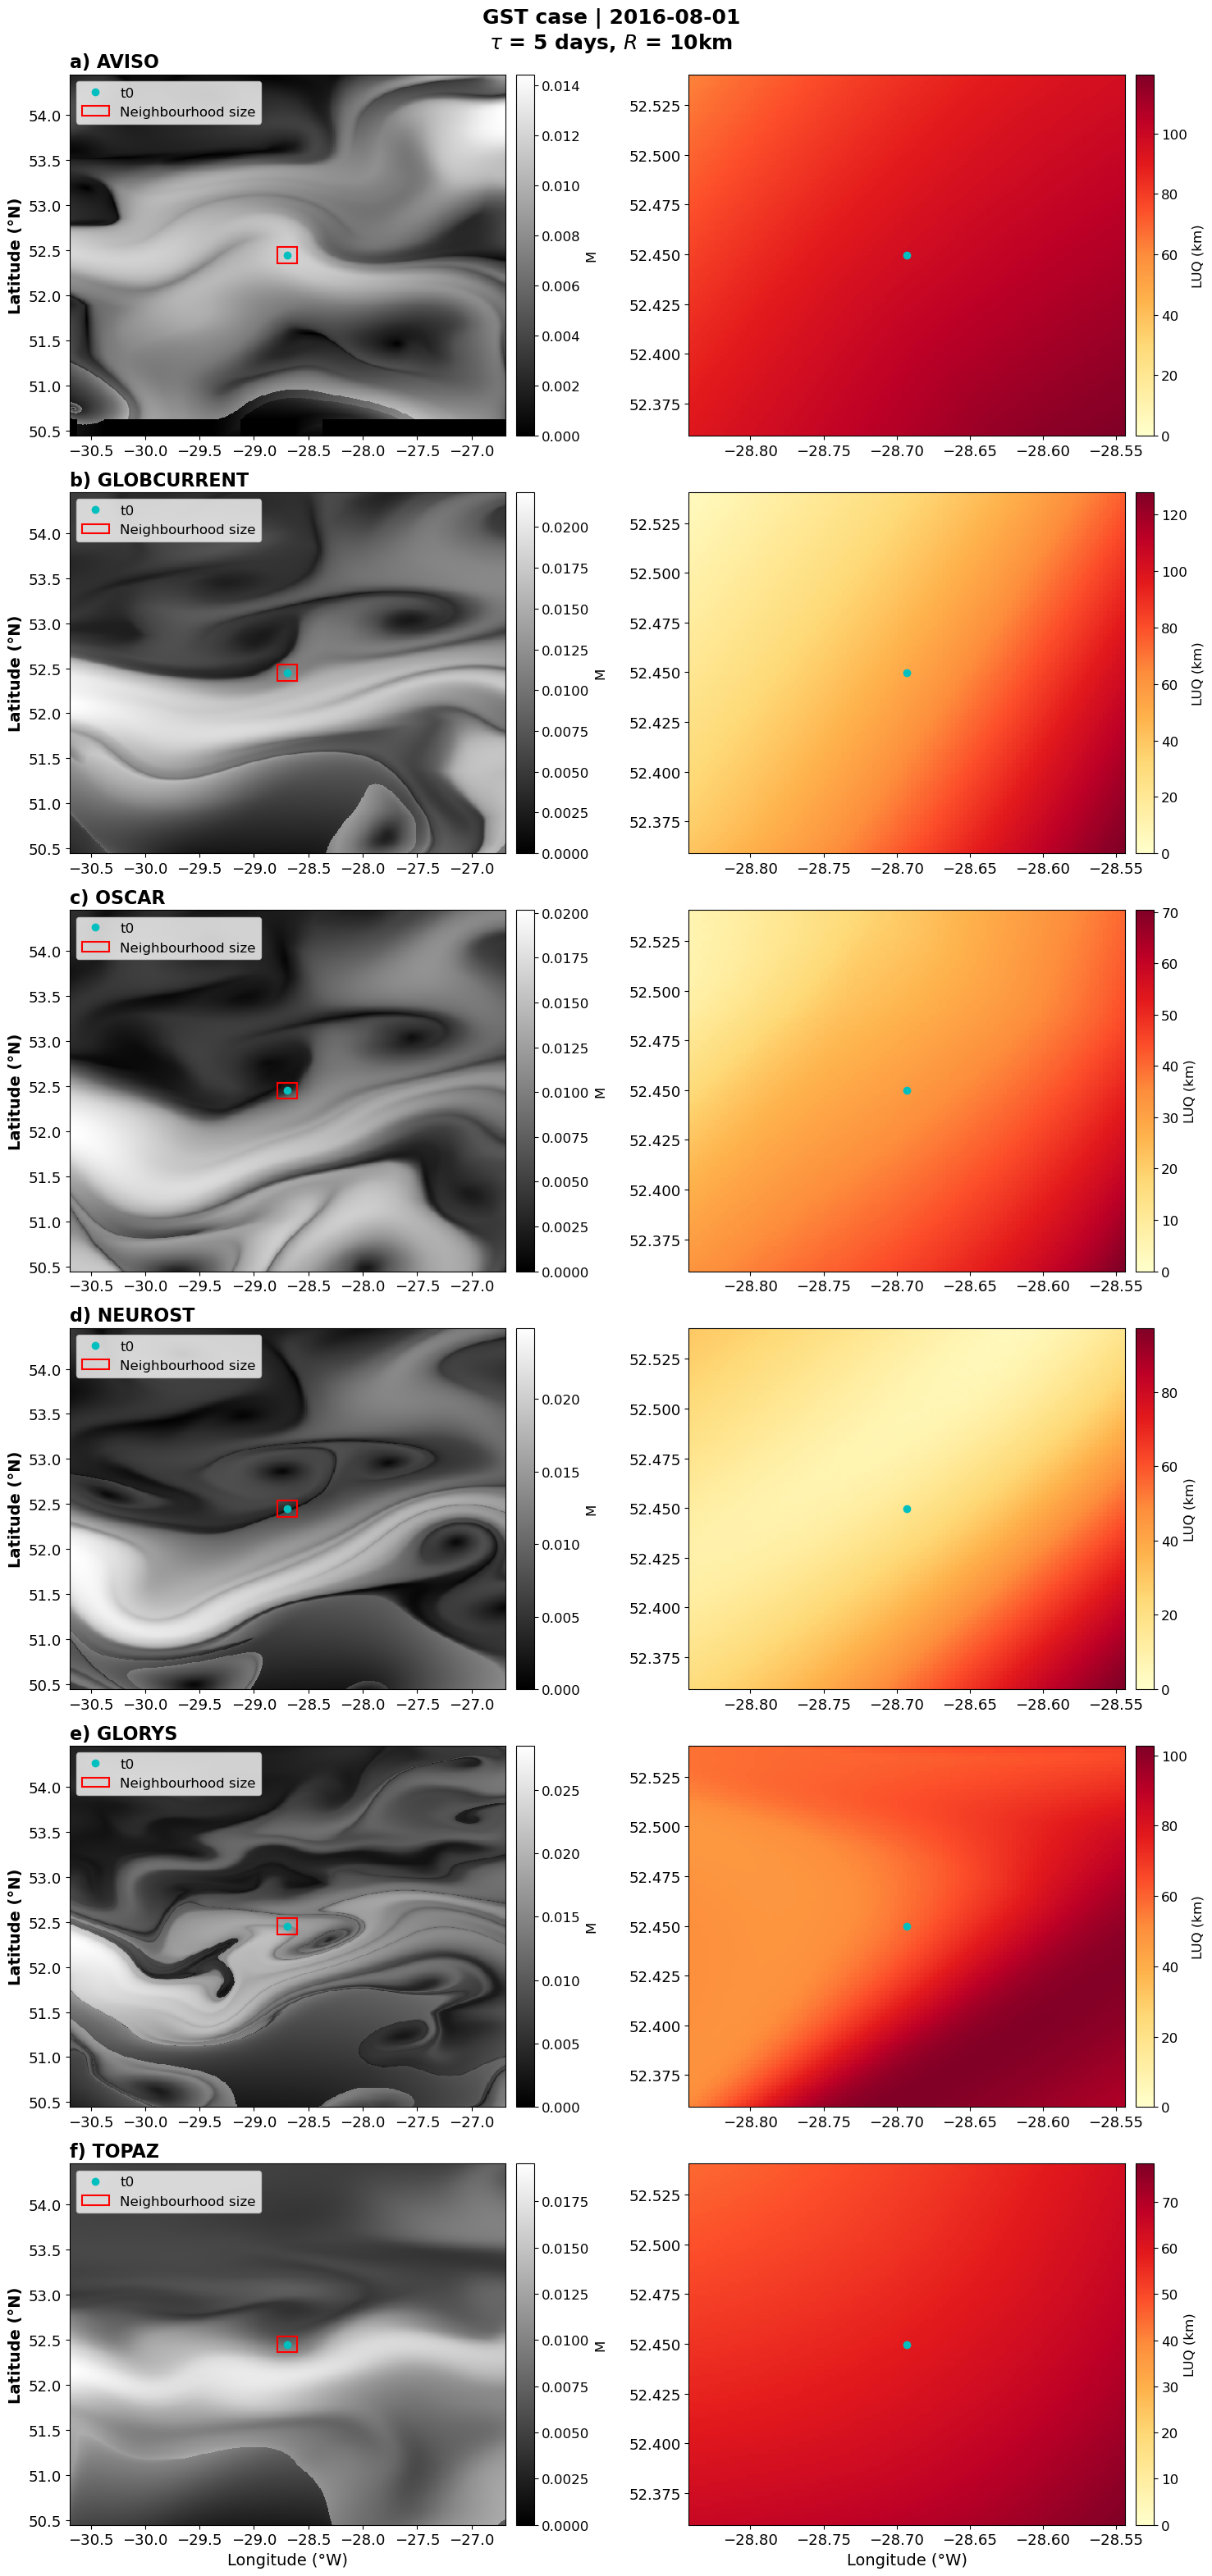

In [8]:
CASE_STUDY = "GST"
TAU_DAYS = 5                         
R_KM = 10

RESULTS_CSV = CASES[CASE_STUDY]["csv"]
T0_STR = CASES[CASE_STUDY]["t0"]
DATASET_NAME = "AVISO"

plot_case_study_matrix(
    case_study_name=CASE_STUDY,
    results_csv=RESULTS_CSV,
    t0_str=T0_STR,
    tau_days=TAU_DAYS,
    r_km=R_KM,
    margin_crop=MARGIN_CROP,
    margin_m_map=MARGIN_M_MAP,
    resolution=RESOLUTION
)